In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import pandas as pd

In [2]:
DATASET_PATH = Path(r"D:\PROJECTS\ML_projects\Dataset collection\FOD-AOriginal-V.2.1\FullDatasetV.2.1-400x400")

In [3]:
folders = [f for f in DATASET_PATH.iterdir() if f.is_dir()]

print("Number of object folders:", len(folders))

print("\nFirst 20 folders:\n")

for folder in folders:
    print(folder.name)  #.folder represents the full path object (e.g., /user/data/dataset_1).folder.name extracts just the final part of that path (e.g., dataset_1).

Number of object folders: 150

First 20 folders:

Battery1
Battery2
Battery2a
Battery3
Bolt1a
BoltWasher1
BoltWasher2
BoltWasher3
BoltWassher1
ClampPart1
ClampPart1a
ClampPart2
ClampPart21a
ClampPart3
Cutter1
Cutter1a
cutter2
Cutter3
Destroyed Plastic Part1
DJI_Bolt1
DJI_LuggageTag1
DJI_LuggageTag2
DJI_Nail1
DJI_Plier1
DJI_Plier2
DJI_Plier3
DJI_Plier4
DJI_Tag1
DJI_Washer1
DJI_Washer2
DJI_Wrench1
FuelCap1
FuelCap2
FuelCap3
GOPR0179_Bolt1
GOPR0180_Bolt1
GOPR0181_Bolt1
GOPR0181_Bolt2
GOPR0181_Bolt3
GOPR0181_Bolt4
GOPR0181_Bolt5
GOPR0182_Nut1
GOPR0182_Nut2
GOPR0183_Nut1
GOPR0183_Nut2
GOPR0184_Bolt1
GOPR0184_Bolt2
GOPR0185_MetalSheet1
GOPR0185_MetalSheet2
GOPR0186_MetalSheet1
GOPR0187_Hose1
GOPR0187_Hose2
GOPR0188_Hose1
GOPR0189_AdjustableClamp1
GOPR0190_AdjustableClamp1
GOPR0191_AdjustableClamp9
GOPR0192_Bolt1
GOPR0193_AdjustableWrench1
GOPR0194_Washer1
GOPR0195_BoltNutset1
GOPR0196_BoltNutset1
GOPR0197_Washer1
GOPR0198_Plier1
GOPR0199_Wrench1
Hammer1
Hammer1a
Hammer2
Hammer3
Hammer4
label

In [4]:
sample = folders[1]

print(sample)

for item in sample.iterdir():
    print(item.name)

D:\PROJECTS\ML_projects\Dataset collection\FOD-AOriginal-V.2.1\FullDatasetV.2.1-400x400\Battery2
Annotations
frame


In [5]:
image_count = {}

for folder in folders:

    frame = folder / "frame"

    if frame.exists():

        images = list(frame.glob("*.png"))

        image_count[folder.name] = len(images)

df = pd.DataFrame({
    "Folder": image_count.keys(),
    "Images": image_count.values()
})

df.sort_values("Images", ascending=False).head(20)

,Folder,Images
30,DJI_Wrench1,1227
22,DJI_Nail1,1005
19,DJI_Bolt1,977
14,Cutter1,838
56,GOPR0192_Bolt1,807
8,BoltWassher1,741
28,DJI_Washer1,738
0,Battery1,700
27,DJI_Tag1,679
63,GOPR0199_Wrench1,660


In [6]:
print("Total Images:", df["Images"].sum())

Total Images: 33863


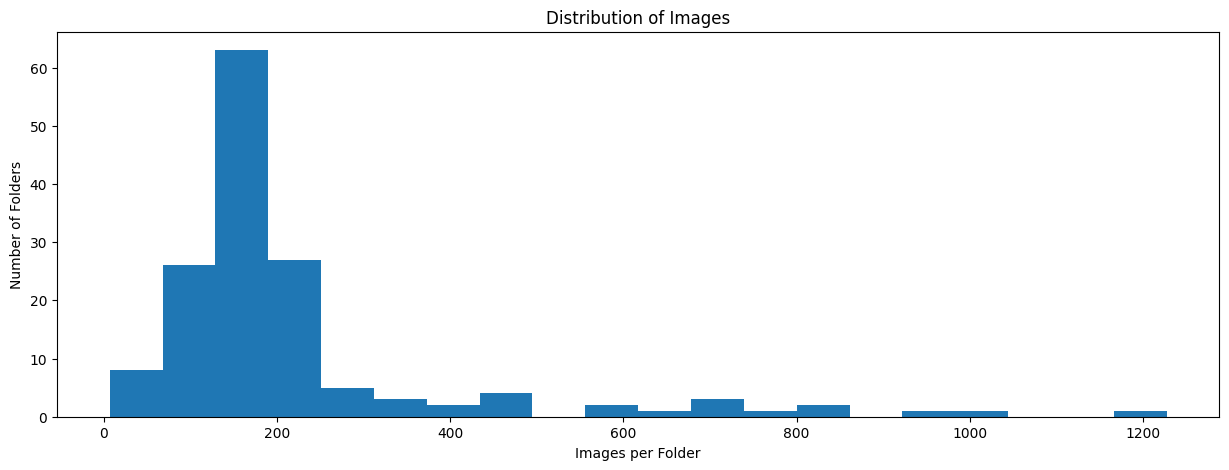

In [7]:
plt.figure(figsize=(15,5))

plt.hist(df["Images"], bins=20)

plt.xlabel("Images per Folder")

plt.ylabel("Number of Folders")

plt.title("Distribution of Images")

plt.show()

In [10]:
sizes = []

for folder in folders:

    frame = folder / "frame"

    if not frame.exists():
        continue

    images = list(frame.glob("*.png"))

    if len(images)==0:
        continue

    img = cv2.imread(str(images[0]))

    h,w = img.shape[:2]

    sizes.append((w,h))

Counter(sizes)

Counter({(400, 400): 150})

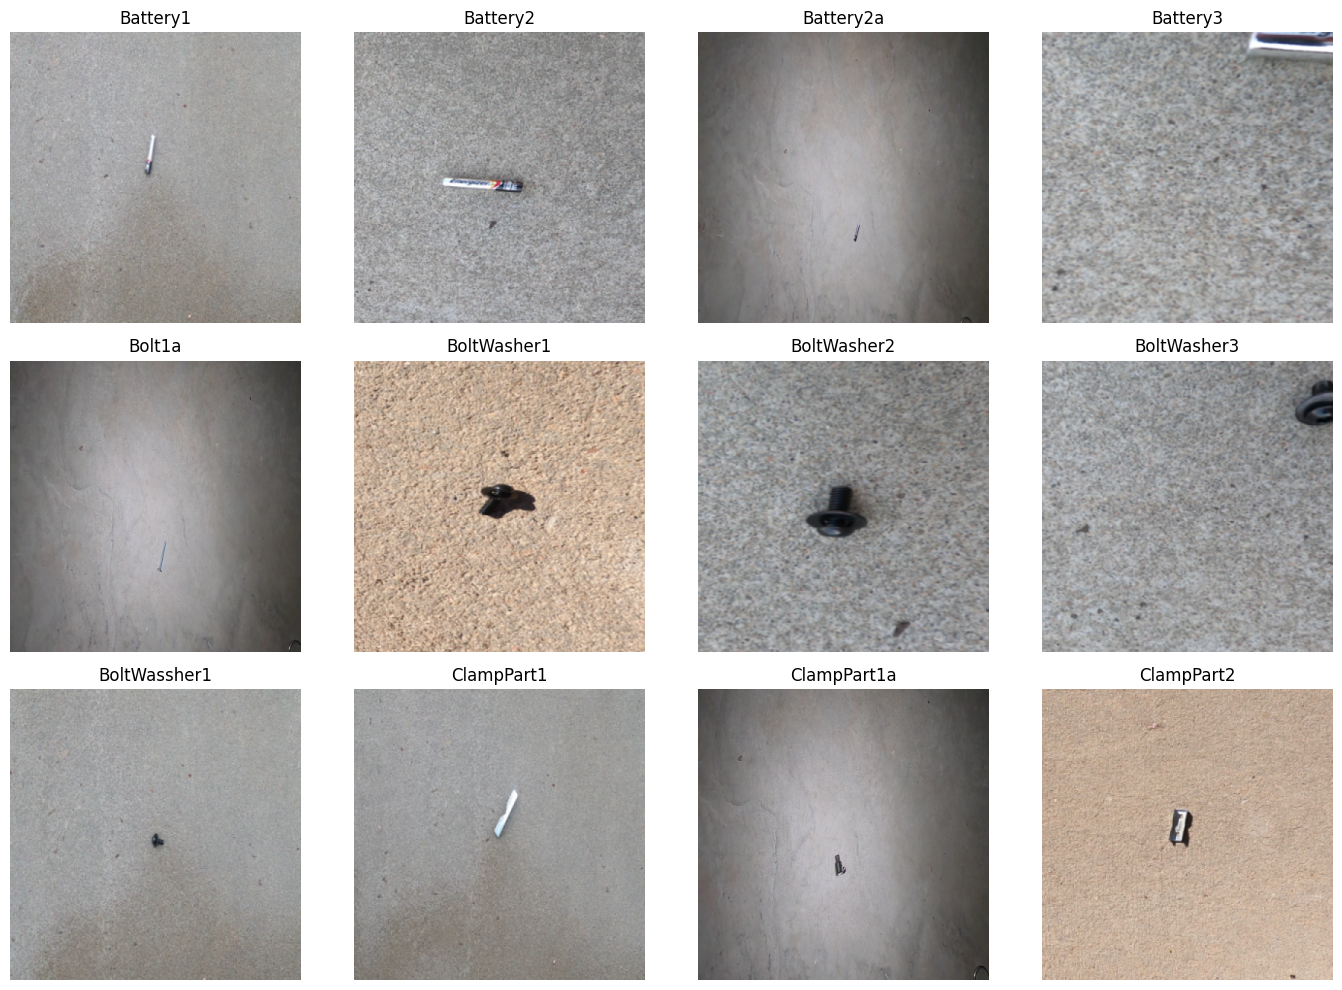

In [9]:
fig, axes = plt.subplots(3,4, figsize=(14,10))

for ax, folder in zip(axes.ravel(), folders[:12]):

    frame = folder/"frame"

    img_path = list(frame.glob("*.png"))[0]

    img = cv2.imread(str(img_path))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)

    ax.set_title(folder.name)

    ax.axis("off")

plt.tight_layout()

In [11]:
import re
from collections import Counter

base_classes = []

for folder in folders:
    name = folder.name

    # Remove trailing numbers and optional letters
    base = re.sub(r"\d+[a-zA-Z]*$", "", name)

    base_classes.append(base)

Counter(base_classes)

Counter({'Wire': 11,
         'PlasticPart': 9,
         'MetalPart': 6,
         'ClampPart': 5,
         'GOPR0181_Bolt': 5,
         'Hammer': 5,
         'Battery': 4,
         'DJI_Plier': 4,
         'Nut': 4,
         'Rock': 4,
         'Screwdriver': 4,
         'Wrench': 4,
         'BoltWasher': 3,
         'Cutter': 3,
         'FuelCap': 3,
         'label': 3,
         'DJI_LuggageTag': 2,
         'DJI_Washer': 2,
         'GOPR0182_Nut': 2,
         'GOPR0183_Nut': 2,
         'GOPR0184_Bolt': 2,
         'GOPR0185_MetalSheet': 2,
         'GOPR0187_Hose': 2,
         'LuggageTag': 2,
         'Paint chip': 2,
         'PaintChip': 2,
         'Pen': 2,
         'Plier': 2,
         'Pliers': 2,
         'Screw': 2,
         'SodaCan': 2,
         'Washer': 2,
         'Bolt': 1,
         'BoltWassher': 1,
         'cutter': 1,
         'Destroyed Plastic Part': 1,
         'DJI_Bolt': 1,
         'DJI_Nail': 1,
         'DJI_Tag': 1,
         'DJI_Wrench': 1,
         

In [24]:
from pathlib import Path
import shutil

# 1. Define source and destination folders with raw string 'r'
folder1 = Path(r"D:\PROJECTS\ML_projects\Dataset collection\FOD-AOriginal-V.2.1\FullDatasetV.2.1-400x400\Battery2a")
folder2 = Path(r"D:\PROJECTS\ML_projects\Dataset collection\FOD-AOriginal-V.2.1\FullDatasetV.2.1-400x400\Battery2")
folder3 = Path(r"D:\PROJECTS\ML_projects\Dataset collection\FOD-AOriginal-V.2.1\FullDatasetV.2.1-400x400\Battery3")
destination = Path(r"D:\PROJECTS\ML_projects\FOD_Project\dataset\battery")

destination.mkdir(parents=True, exist_ok=True)
image_counter = 1
source_folders = [folder1, folder2,folder3]

for folder in source_folders:
    print(f"\nScanning: {folder.name}...")
    
    if not folder.exists():
        print(f"❌ Error: The directory '{folder}' does not exist! Check the spelling.")
        continue

    # FIX 1 & 2: Use rglob to scan recursively down into subfolders
    # Use [pP][nN][gG] to match .png, .PNG, .Png etc.
    images = sorted(list(folder.rglob("*.[pP][nN][gG]")))
    
    if not images:
        print("❓ No PNG images found here. Let's see what files ARE inside this folder:")
        # Show the first 5 files actually found to help debug extensions/paths
        all_files = list(folder.iterdir())[:5]
        for f in all_files:
            print(f"  - Found file/folder: {f.name}")
        continue

    print(f"📸 Found {len(images)} images! Copying...")
    for img_path in images:
        new_name = f"image_{image_counter:05d}.png"
        new_path = destination / new_name
        
        shutil.copy(img_path, new_path)
        image_counter += 1

print(f"\n✅ Done! Successfully merged {image_counter - 1} images into '{destination.name}'!")



Scanning: Battery2a...
📸 Found 173 images! Copying...

Scanning: Battery2...
📸 Found 121 images! Copying...

Scanning: Battery3...
📸 Found 65 images! Copying...

✅ Done! Successfully merged 359 images into 'battery'!
